# Connect Forest Management Model with Forest Carbon Budget Model (without calibration)

## Set up Modelling Environment

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
import ws3.forest
import time
import gurobipy as grb
import pickle
import libcbm
import os
from util_opt import compile_events, cbm_report, compile_scenario_maxstock, plot_scenario_maxstock, run_cbm_emissionstock, run_scenario, plugin_c_curves, plugin_c_curves_both, cbm_report_both, compare_ws3_cbm, compare_ws3_cbm_both, track_system_stock, track_system_emission, compile_scenario_minemission, plot_scenario_minemission, kpi_age, kpi_species, cmp_c_ss, cmp_c_se, results_scenarios

In [2]:
def select_case_study(case_study):
    print(f"Selected scenario: {case_study}")
case_study_dropdown = widgets.Dropdown(
    options=['redchris', 'goldenbear', 'equitysilver', 'test'],
    value='test',
    description='Case Study:'
)
display(case_study_dropdown)
case_study_dropdown.observe(lambda change: select_case_study(change['new']), names='value')

Dropdown(description='Case Study:', index=3, options=('redchris', 'goldenbear', 'equitysilver', 'test'), value…

In [3]:
case_study = case_study_dropdown.value

In [4]:
#Start Calculating the Running Time
Start = time.time()

In [5]:
base_year = 2020
horizon = 10
period_length = 10
max_age = 1000
n_steps = 100
tvy_name = 'totvol'

In [6]:
# Define case study mappings
case_study_options = {
    'redchris': {
        'model_name': 'redchris',
        'model_path': './data/woodstock_model_files_redchris'
    },
    'goldenbear': {
        'model_name': 'goldenbear',
        'model_path': './data/woodstock_model_files_goldenbear'
    },
    'equitysilver': {
        'model_name': 'equitysilver',
        'model_path': './data/woodstock_model_files_equitysilver'
    },
    'test': {
        'model_name': 'redchris',
        'model_path': './data/woodstock_model_files_redchris_test'
    }
}

# Retrieve model details based on case study
model_info = case_study_options.get(case_study)

if model_info:
    model_name = model_info['model_name']
    model_path = model_info['model_path']
else:
    print('The case study name is not valid')


In [7]:
# Create and Run `ForestModel` instance
fm = ws3.forest.ForestModel(model_name=model_name,
                            model_path=model_path,
                            base_year=base_year,
                            horizon=horizon,
                            period_length=period_length,
                            max_age=max_age)
fm.import_landscape_section()
fm.import_areas_section()
fm.import_yields_section()
fm.import_actions_section()
fm.import_transitions_section()
fm.initialize_areas()
fm.add_null_action()
fm.reset_actions()
fm.grow()

In [8]:
# Flag 'harvest' as a harvesting action in the ws3 model
harvest_acode='harvest'
fm.actions[harvest_acode].is_harvest = True

(<Figure size 2000x500 with 5 Axes>,
 array([<Axes: title={'center': 'Harvested area'}, xlabel='Period', ylabel='Area (ha)'>,
        <Axes: title={'center': 'Harvested volume'}, xlabel='Period', ylabel='Volume (m3)'>,
        <Axes: title={'center': 'Growing Stock'}, xlabel='Period', ylabel='Volume (m3)'>,
        <Axes: title={'center': 'Ecosystem C stock'}, xlabel='Period', ylabel='Stock (ton)'>,
        <Axes: title={'center': 'Net Carbon Emission'}, xlabel='Period', ylabel='tons of CO2'>],
       dtype=object))

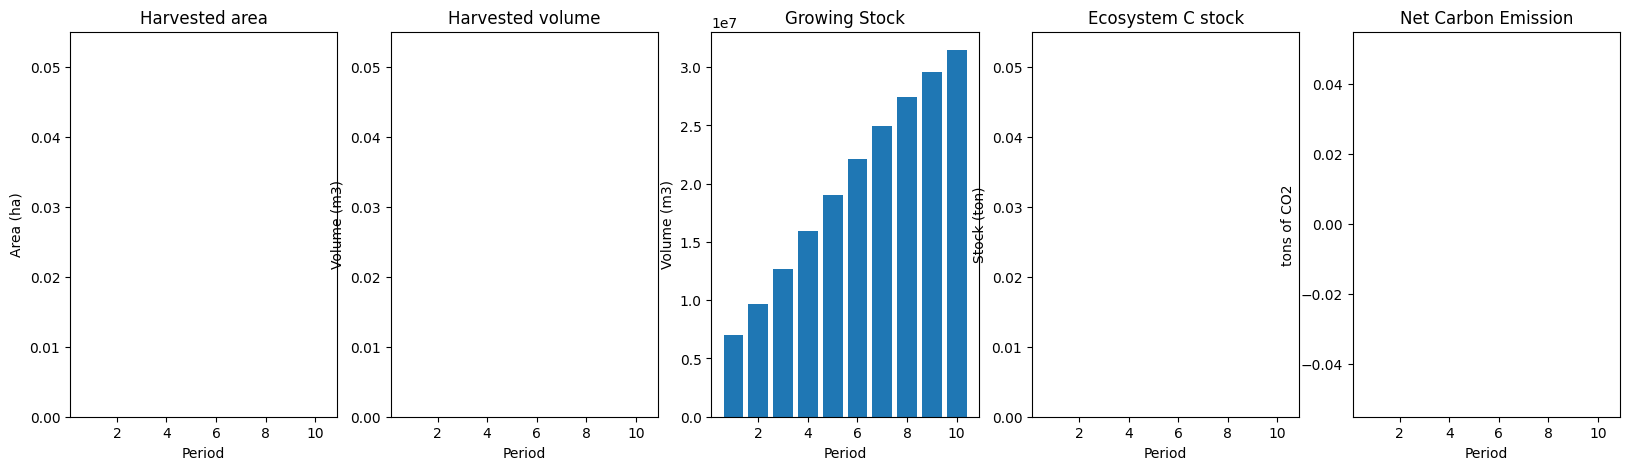

In [9]:
# Check the Forest Inventory of the Forest Model
df = compile_scenario_minemission(fm)
plot_scenario_minemission(df)

## Hard-link `ForestModel` to `libcbm`

Prepare CBM input files

In [10]:
# Define Disturance Types
disturbance_type_mapping = [{'user_dist_type': 'harvest', 'default_dist_type': 'Clearcut harvesting without salvage'},
                            {'user_dist_type': 'fire', 'default_dist_type': 'Wildfire'}]
for dtype_key in fm.dtypes:
    fm.dt(dtype_key).last_pass_disturbance = 'fire' if dtype_key[2] == dtype_key[4] else 'harvest'

In [11]:
sit_config, sit_tables = fm.to_cbm_sit(softwood_volume_yname='swdvol', 
                                       hardwood_volume_yname='hwdvol', 
                                       admin_boundary='British Columbia', 
                                       eco_boundary='Montane Cordillera',
                                       disturbance_type_mapping=disturbance_type_mapping)

Here are other two ways to generate sit tables. But they are only suitbale for small forest model since they take too much running time and memory

In [12]:
# Define Time Steps
n_steps = fm.horizon * fm.period_length

# Run CBM and Generate CBM 0utputs
cbm_output = run_cbm_emissionstock(sit_config, sit_tables, n_steps)

Emissions from all biomass components only resulting from fire disturbance, while these from all DOM pools resulting from annual decay processes and fire disturbance.

In [13]:
# Define Carbon Pools
biomass_pools = ['SoftwoodMerch','SoftwoodFoliage', 'SoftwoodOther', 'SoftwoodCoarseRoots','SoftwoodFineRoots',                        
                 'HardwoodMerch', 'HardwoodFoliage', 'HardwoodOther', 'HardwoodCoarseRoots', 'HardwoodFineRoots']
dom_pools = ['AboveGroundVeryFastSoil', 'BelowGroundVeryFastSoil', 'AboveGroundFastSoil', 'BelowGroundFastSoil',
             'MediumSoil', 'AboveGroundSlowSoil', 'BelowGroundSlowSoil', 'SoftwoodStemSnag', 'SoftwoodBranchSnag',
             'HardwoodStemSnag', 'HardwoodBranchSnag']
emissions_pools = ['CO2', 'CH4', 'CO', 'NO2']
products_pools = ['Products']
ecosystem_pools = biomass_pools + dom_pools
all_pools = biomass_pools + dom_pools + emissions_pools + products_pools

In [14]:
# Define Carbon Fluxes
all_fluxes = [
    'DisturbanceCO2Production',
    'DisturbanceCH4Production',
    'DisturbanceCOProduction',
    'DisturbanceBioCO2Emission',
    'DisturbanceBioCH4Emission',
    'DisturbanceBioCOEmission',
    'DecayDOMCO2Emission',
    'DisturbanceSoftProduction',
    'DisturbanceHardProduction',
    'DisturbanceDOMProduction',
    'DeltaBiomass_AG',
    'DeltaBiomass_BG',
    'TurnoverMerchLitterInput',
    'TurnoverFolLitterInput',
    'TurnoverOthLitterInput',
    'TurnoverCoarseLitterInput',
    'TurnoverFineLitterInput',
    'DecayVFastAGToAir',
    'DecayVFastBGToAir',
    'DecayFastAGToAir',
    'DecayFastBGToAir',
    'DecayMediumToAir',
    'DecaySlowAGToAir',
    'DecaySlowBGToAir',
    'DecaySWStemSnagToAir',
    'DecaySWBranchSnagToAir',
    'DecayHWStemSnagToAir',
    'DecayHWBranchSnagToAir',
    'DisturbanceMerchToAir',
    'DisturbanceFolToAir',
    'DisturbanceOthToAir',
    'DisturbanceCoarseToAir',
    'DisturbanceFineToAir',
    'DisturbanceDOMCO2Emission',
    'DisturbanceDOMCH4Emission',
    'DisturbanceDOMCOEmission',
    'DisturbanceMerchLitterInput',
    'DisturbanceFolLitterInput',
    'DisturbanceOthLitterInput',
    'DisturbanceCoarseLitterInput',
    'DisturbanceFineLitterInput',
    'DisturbanceVFastAGToAir',
    'DisturbanceVFastBGToAir',
    'DisturbanceFastAGToAir',
    'DisturbanceFastBGToAir',
    'DisturbanceMediumToAir',
    'DisturbanceSlowAGToAir',
    'DisturbanceSlowBGToAir',
    'DisturbanceSWStemSnagToAir',
    'DisturbanceSWBranchSnagToAir',
    'DisturbanceHWStemSnagToAir',
    'DisturbanceHWBranchSnagToAir'
]
ecosystem_decay_emissions_pools = [
    'DecayVFastAGToAir',
    'DecayVFastBGToAir',
    'DecayFastAGToAir',
    'DecayFastBGToAir',
    'DecayMediumToAir',
    'DecaySlowAGToAir',
    'DecaySlowBGToAir',
    'DecaySWStemSnagToAir',
    'DecaySWBranchSnagToAir',
    'DecayHWStemSnagToAir',
    'DecayHWBranchSnagToAir']
GrossGrowth_pools = [
    'DeltaBiomass_AG',
    'TurnoverMerchLitterInput',
    'TurnoverFolLitterInput',
    'TurnoverOthLitterInput',
    'DeltaBiomass_BG',
    'TurnoverCoarseLitterInput',
    'TurnoverFineLitterInput']

In [15]:
# Define Sum Carbon Pools and Sum Carbon Fluxes
pools = ecosystem_pools
fluxes = ecosystem_decay_emissions_pools
gross_growth = GrossGrowth_pools
sum_pools = ['ecosystem', 'biomass', 'DOM']

,Biomass,DOM,Ecosystem,All_Emissions,Gross_Growth,Stock_Change
Year,,,,,,
0,7.144077e+06,2.015607e+07,2.730015e+07,0.000000,0.000000,0.000000
1,7.276708e+06,2.017834e+07,2.745505e+07,416674.280733,571575.647093,-154901.366361
2,7.409069e+06,2.020236e+07,2.761143e+07,419715.380098,576091.686330,-156376.306232
3,7.540872e+06,2.022798e+07,2.776885e+07,422789.528036,580213.676778,-157424.148742
4,7.672226e+06,2.025507e+07,2.792730e+07,425883.858112,584327.359615,-158443.501503
...,...,...,...,...,...,...
96,1.649951e+07,2.465068e+07,4.115019e+07,608514.425281,706817.788031,-98303.362750
97,1.654539e+07,2.470173e+07,4.124712e+07,609562.297104,706489.331653,-96927.034549
98,1.659022e+07,2.475263e+07,4.134285e+07,610594.704835,706318.529561,-95723.824726


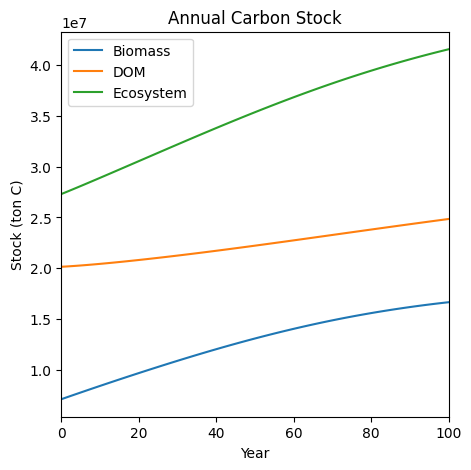

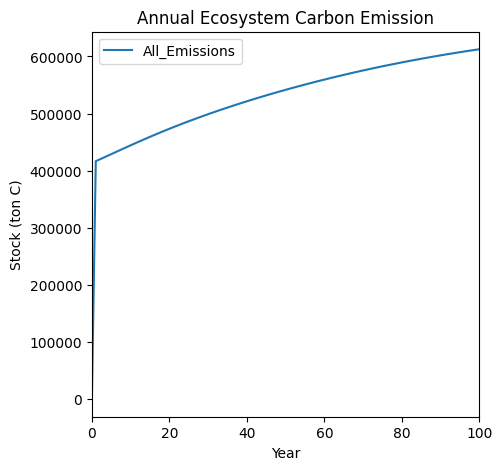

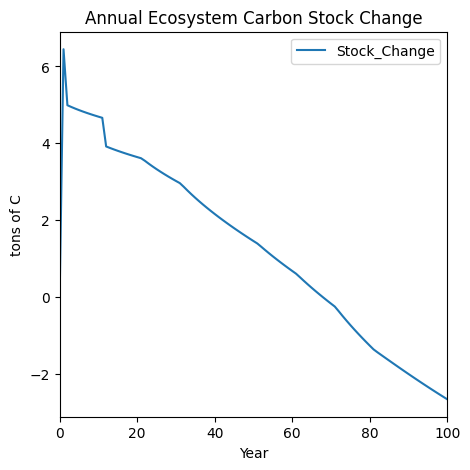

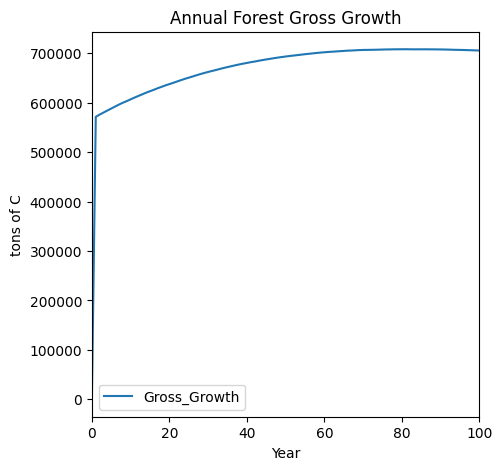

In [16]:
# Report Annual CBM Results
cbm_report(fm, cbm_output, biomass_pools, dom_pools, fluxes, gross_growth)

## Plug-in Carbon Yield Curves

In [17]:
# Read curves
file_directory = "./inputs/curves"
file_names = [f"{case_study}_c_curves_p.pkl", f"{case_study}_c_curves_f.pkl"]
loaded_data = {}

for filename in file_names:
    file_path = os.path.join(file_directory, filename)
    with open(file_path, 'rb') as file:
        loaded_data[filename] = pickle.load(file)
    print(f"Loaded data from {file_path}")

c_curves_p = loaded_data.get(f"{case_study}_c_curves_p.pkl")
c_curves_f = loaded_data.get(f"{case_study}_c_curves_f.pkl")

Loaded data from ./inputs/curves/goldenbear_c_curves_p.pkl
Loaded data from ./inputs/curves/goldenbear_c_curves_f.pkl


In [18]:
# Plug carbon yield curves into forest model
# plugin_c_curves(fm, c_curves_p, pools=sum_pools) #Plugs in only c_curves_p
plugin_c_curves_both(fm, c_curves_p, c_curves_f, pools=sum_pools, fluxes=['net_emissions', 'total_emissions', 'gross_growth'])

found match for mask ('?', '?', '?', '?', '12', '12')
found match for mask ('?', '?', '?', '?', '30', '30')
found match for mask ('?', '?', '?', '?', '10', '10')
found match for mask ('?', '?', '?', '?', '12', '12')
found match for mask ('?', '?', '?', '?', '28', '28')
found match for mask ('?', '?', '?', '?', '30', '30')
found match for mask ('?', '?', '?', '?', '10', '10')
found match for mask ('?', '?', '?', '?', '11', '11')
found match for mask ('?', '?', '?', '?', '12', '12')
found match for mask ('?', '?', '?', '?', '28', '28')
found match for mask ('?', '?', '?', '?', '29', '29')
found match for mask ('?', '?', '?', '?', '30', '30')
found match for mask ('?', '?', '?', '?', '37', '37')
found match for mask ('?', '?', '?', '?', '38', '38')
found match for mask ('?', '?', '?', '?', '39', '39')
found match for mask ('?', '?', '?', '?', '25', '25')
found match for mask ('?', '?', '?', '?', '27', '27')
found match for mask ('?', '?', '?', '?', '7', '7')
found match for mask ('?', '?'

In [19]:
# Check if all carbon yield curves are plugged in well.
fm.yields

[(('?', '?', '?', '?', '?', '?'), '', []),
 (('?', '?', '?', '?', '7', '7'),
  'a',
  [('s0100', <ws3.core.Curve at 0x7f02b85e67a0>),
   ('ecosystem', <ws3.core.Curve at 0x7f02a9844a60>),
   ('biomass', <ws3.core.Curve at 0x7f02a97975e0>),
   ('DOM', <ws3.core.Curve at 0x7f02a9797b80>),
   ('net_emissions', <ws3.core.Curve at 0x7f02a96bdba0>),
   ('total_emissions', <ws3.core.Curve at 0x7f02a9796620>),
   ('gross_growth', <ws3.core.Curve at 0x7f02a9796ad0>),
   ('ecosystem', <ws3.core.Curve at 0x7f02a9844a60>),
   ('biomass', <ws3.core.Curve at 0x7f02a97975e0>),
   ('DOM', <ws3.core.Curve at 0x7f02a9797b80>),
   ('net_emissions', <ws3.core.Curve at 0x7f02a96bdba0>),
   ('total_emissions', <ws3.core.Curve at 0x7f02a9796620>),
   ('gross_growth', <ws3.core.Curve at 0x7f02a9796ad0>),
   ('ecosystem', <ws3.core.Curve at 0x7f02a9844a60>),
   ('biomass', <ws3.core.Curve at 0x7f02a97975e0>),
   ('DOM', <ws3.core.Curve at 0x7f02a9797b80>),
   ('net_emissions', <ws3.core.Curve at 0x7f02a96bdba0

(<Figure size 2000x500 with 5 Axes>,
 array([<Axes: title={'center': 'Harvested area'}, xlabel='Period', ylabel='Area (ha)'>,
        <Axes: title={'center': 'Harvested volume'}, xlabel='Period', ylabel='Volume (m3)'>,
        <Axes: title={'center': 'Growing Stock'}, xlabel='Period', ylabel='Volume (m3)'>,
        <Axes: title={'center': 'Ecosystem C stock'}, xlabel='Period', ylabel='Stock (ton)'>,
        <Axes: title={'center': 'Net Carbon Emission'}, xlabel='Period', ylabel='tons of CO2'>],
       dtype=object))

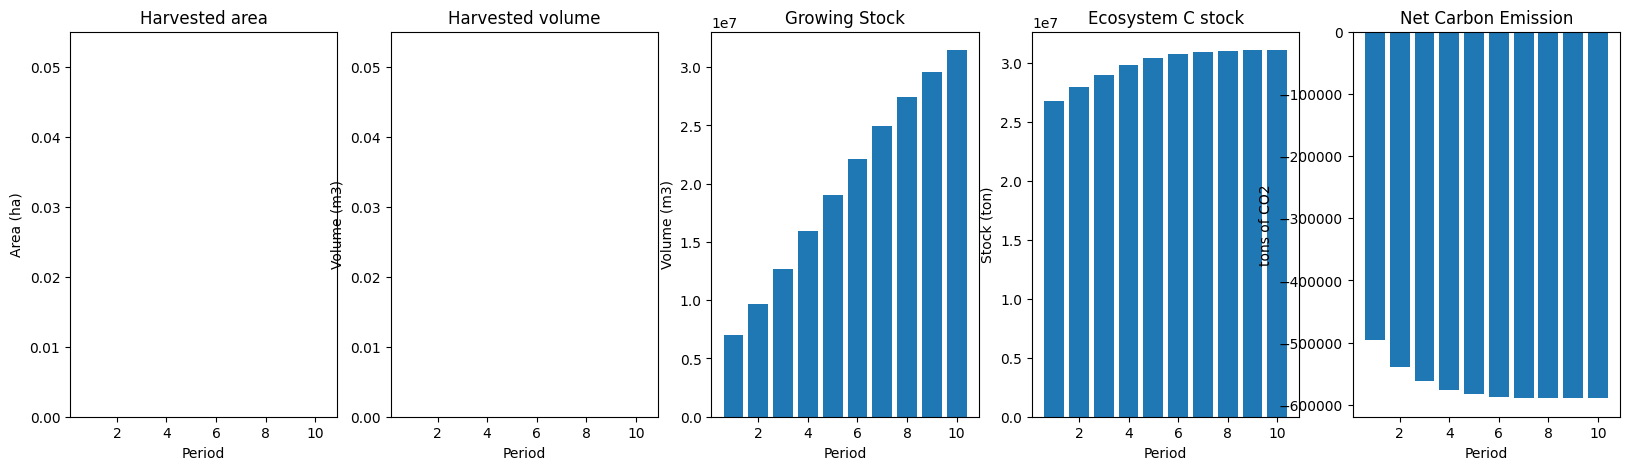

In [20]:
# Check the Forest Inventory of the ws3 Model without harvesting
df = compile_scenario_minemission(fm)
plot_scenario_minemission(df)

In [21]:
#Define Basic Variables
softwood_volume_yname='swdvol' 
hardwood_volume_yname='hwdvol'
n_yield_vals=100

In [22]:
#Generate New Sit_events file
sit_events = compile_events(fm, softwood_volume_yname, hardwood_volume_yname, n_yield_vals)

In [23]:
# Replace the Sit_events file in the sit tables
sit_tables['sit_events'] = sit_events

In [24]:
sit_events

,theme0,theme1,theme2,theme3,theme4,theme5,species,using_age_class,min_softwood_age,max_softwood_age,...,MinSWMerchStemSnagC,MaxSWMerchStemSnagC,MinHWMerchStemSnagC,MaxHWMerchStemSnagC,efficiency,sort_type,target_type,target,disturbance_type,disturbance_year


In [25]:
# Run CBM and Generate CBM Ouputs
cbm_output = run_cbm_emissionstock(sit_config, sit_tables, n_steps)

,Biomass,DOM,Ecosystem,All_Emissions,Gross_Growth,Stock_Change,Net_Emissions
Year,,,,,,,
0,7.144077e+06,2.015607e+07,2.730015e+07,0.000000e+00,0.000000e+00,0.000000,0.000000
1,7.276708e+06,2.017834e+07,2.745505e+07,1.527806e+06,-2.095777e+06,-154901.366361,-567971.676655
2,7.409069e+06,2.020236e+07,2.761143e+07,1.538956e+06,-2.112336e+06,-156376.306232,-573379.789517
3,7.540872e+06,2.022798e+07,2.776885e+07,1.550228e+06,-2.127450e+06,-157424.148742,-577221.878720
4,7.672226e+06,2.025507e+07,2.792730e+07,1.561574e+06,-2.142534e+06,-158443.501503,-580959.505510
...,...,...,...,...,...,...,...
96,1.649951e+07,2.465068e+07,4.115019e+07,2.231220e+06,-2.591665e+06,-98303.362750,-360445.663418
97,1.654539e+07,2.470173e+07,4.124712e+07,2.235062e+06,-2.590461e+06,-96927.034549,-355399.126681
98,1.659022e+07,2.475263e+07,4.134285e+07,2.238847e+06,-2.589835e+06,-95723.824726,-350987.357327


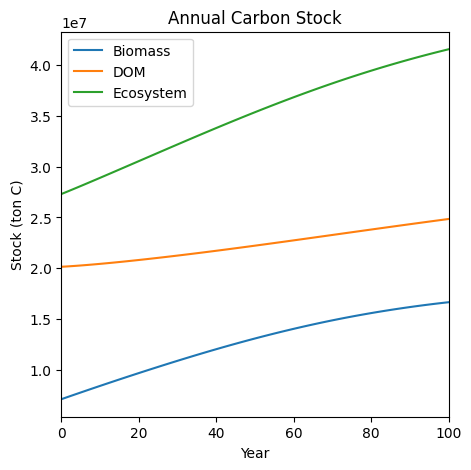

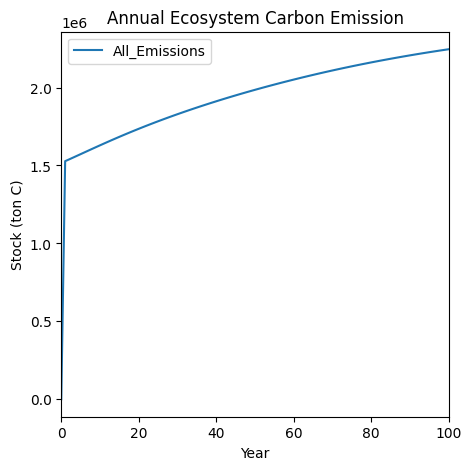

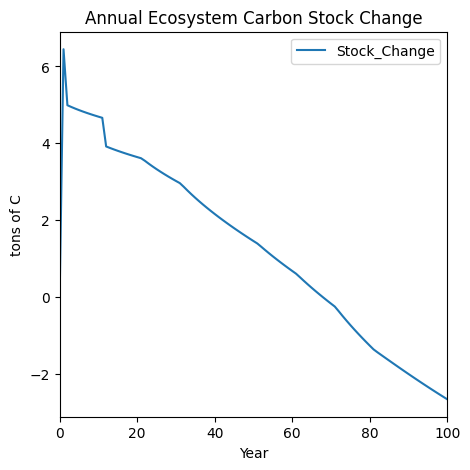

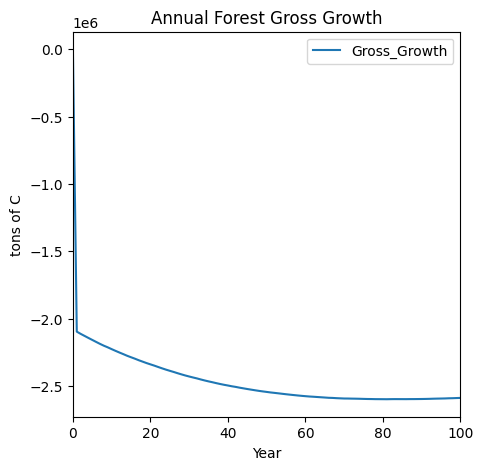

In [26]:
# Report Annual CBM Outputs
# cbm_report(fm, cbm_output, biomass_pools, dom_pools, fluxes, gross_growth)
cbm_report_both(fm, cbm_output, biomass_pools, dom_pools, fluxes, gross_growth)

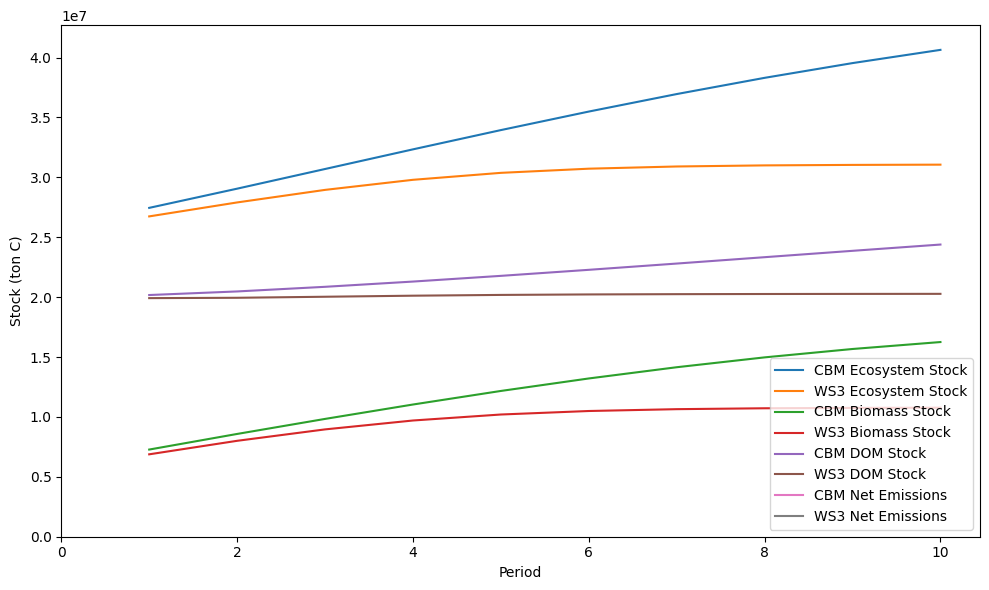

(   period  biomass_stock     dom_stock     eco_stock  \
 0       1   7.276708e+06  2.017834e+07  2.745505e+07   
 1       2   8.580022e+06  2.047770e+07  2.905772e+07   
 2       3   9.835231e+06  2.086421e+07  3.069944e+07   
 3       4   1.103725e+07  2.130245e+07  3.233970e+07   
 4       5   1.216982e+07  2.177869e+07  3.394851e+07   
 5       6   1.321264e+07  2.228288e+07  3.549552e+07   
 6       7   1.415046e+07  2.280562e+07  3.695608e+07   
 7       8   1.497324e+07  2.333740e+07  3.831064e+07   
 8       9   1.567309e+07  2.386886e+07  3.954195e+07   
 9      10   1.625298e+07  2.439306e+07  4.064605e+07   
 
    ecosystem_decay_emissions  gross_growth  net_emissions  eco_stock_change  
 0               1.527806e+06 -2.095777e+06 -567971.676655      0.000000e+00  
 1               1.640677e+06 -2.238486e+06 -597808.609559      1.602670e+06  
 2               1.745594e+06 -2.348021e+06 -602427.119787      1.641716e+06  
 3               1.838118e+06 -2.436049e+06 -597931.163

In [27]:
# Compare the carbon outputs from ws3 (table above) and libcbm (table below)
# compare_ws3_cbm(fm, cbm_output, disturbance_type_mapping, biomass_pools, dom_pools, plots='whole')
compare_ws3_cbm_both(fm, cbm_output, disturbance_type_mapping, biomass_pools, dom_pools, ecosystem_decay_emissions_pools, GrossGrowth_pools, plots="whole")

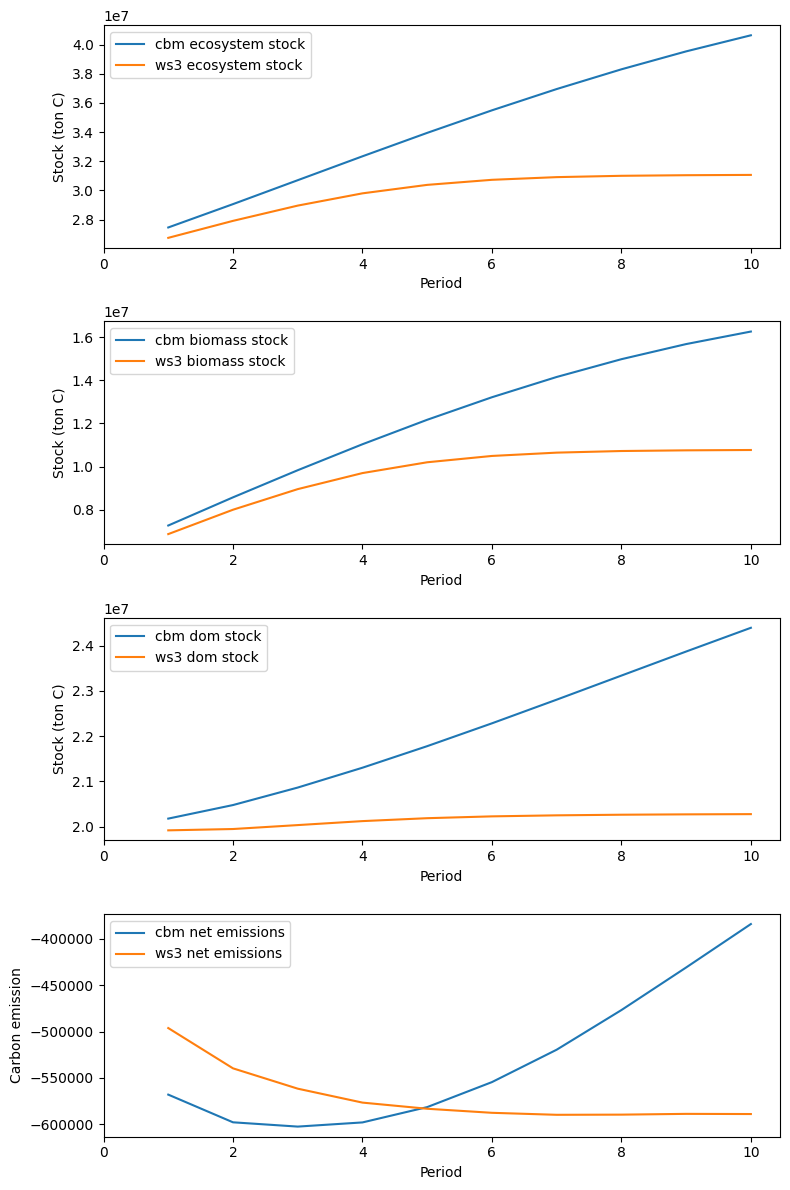

(   period  biomass_stock     dom_stock     eco_stock  \
 0       1   7.276708e+06  2.017834e+07  2.745505e+07   
 1       2   8.580022e+06  2.047770e+07  2.905772e+07   
 2       3   9.835231e+06  2.086421e+07  3.069944e+07   
 3       4   1.103725e+07  2.130245e+07  3.233970e+07   
 4       5   1.216982e+07  2.177869e+07  3.394851e+07   
 5       6   1.321264e+07  2.228288e+07  3.549552e+07   
 6       7   1.415046e+07  2.280562e+07  3.695608e+07   
 7       8   1.497324e+07  2.333740e+07  3.831064e+07   
 8       9   1.567309e+07  2.386886e+07  3.954195e+07   
 9      10   1.625298e+07  2.439306e+07  4.064605e+07   
 
    ecosystem_decay_emissions  gross_growth  net_emissions  eco_stock_change  
 0               1.527806e+06 -2.095777e+06 -567971.676655      0.000000e+00  
 1               1.640677e+06 -2.238486e+06 -597808.609559      1.602670e+06  
 2               1.745594e+06 -2.348021e+06 -602427.119787      1.641716e+06  
 3               1.838118e+06 -2.436049e+06 -597931.163

In [28]:
# Compare the carbon outputs from ws3 (table above) and libcbm (table below)
# compare_ws3_cbm(fm, cbm_output, disturbance_type_mapping, biomass_pools, dom_pools, plots='individual')
compare_ws3_cbm_both(fm, cbm_output, disturbance_type_mapping, biomass_pools, dom_pools, ecosystem_decay_emissions_pools, GrossGrowth_pools, plots="individual")

(<Figure size 1600x400 with 5 Axes>,
 array([<Axes: title={'center': 'Solid Wood Product C Stock'}, xlabel='Period', ylabel='Stock (tons)'>,
        <Axes: title={'center': 'Paper Product C Stock'}, xlabel='Period', ylabel='Stock (tons)'>,
        <Axes: title={'center': 'Total Product C Stock'}, xlabel='Period', ylabel='Stock (tons)'>,
        <Axes: title={'center': 'Ecosystem C Stock'}, xlabel='Period', ylabel='Stock (tons)'>,
        <Axes: title={'center': 'Total System C Stock'}, xlabel='Period', ylabel='Stock (tons)'>],
       dtype=object),
    period  solid_wood  paper  sum_product     ecosystem        system
 0       1         0.0    0.0          0.0  2.674304e+07  2.674304e+07
 1       2         0.0    0.0          0.0  2.790846e+07  2.790846e+07
 2       3         0.0    0.0          0.0  2.895609e+07  2.895609e+07
 3       4         0.0    0.0          0.0  2.979727e+07  2.979727e+07
 4       5         0.0    0.0          0.0  3.037906e+07  3.037906e+07
 5       6         

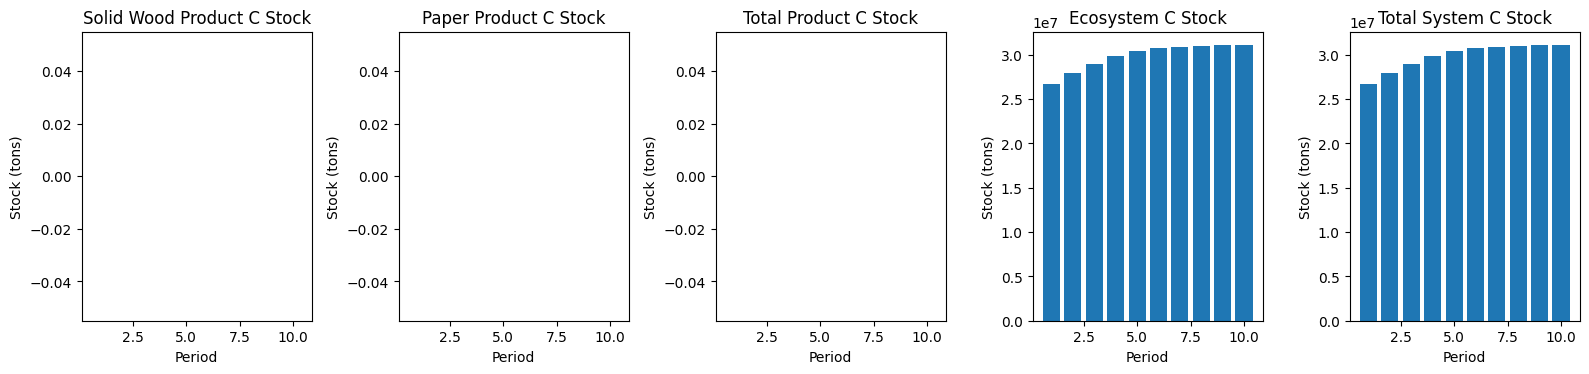

In [29]:
track_system_stock(fm)

(<Figure size 1600x400 with 5 Axes>,
 array([<Axes: title={'center': 'Solid Wood Product CO2 Emission'}, xlabel='Period', ylabel='Emission (tons)'>,
        <Axes: title={'center': 'Paper Product CO2 Emission'}, xlabel='Period', ylabel='Emission (tons)'>,
        <Axes: title={'center': 'Total Product CO2 Emission'}, xlabel='Period', ylabel='Emission (tons)'>,
        <Axes: title={'center': 'Ecosystem CO2 Emission'}, xlabel='Period', ylabel='Emission (tons)'>,
        <Axes: title={'center': 'Total System CO2 Emission'}, xlabel='Period', ylabel='Emission (tons)'>],
       dtype=object),
    period  solid_wood  paper  sum_product     ecosystem        system
 0       1         0.0    0.0          0.0  0.000000e+00  0.000000e+00
 1       2         0.0    0.0          0.0 -4.273218e+06 -4.273218e+06
 2       3         0.0    0.0          0.0 -3.841283e+06 -3.841283e+06
 3       4         0.0    0.0          0.0 -3.084323e+06 -3.084323e+06
 4       5         0.0    0.0          0.0 -2.1332

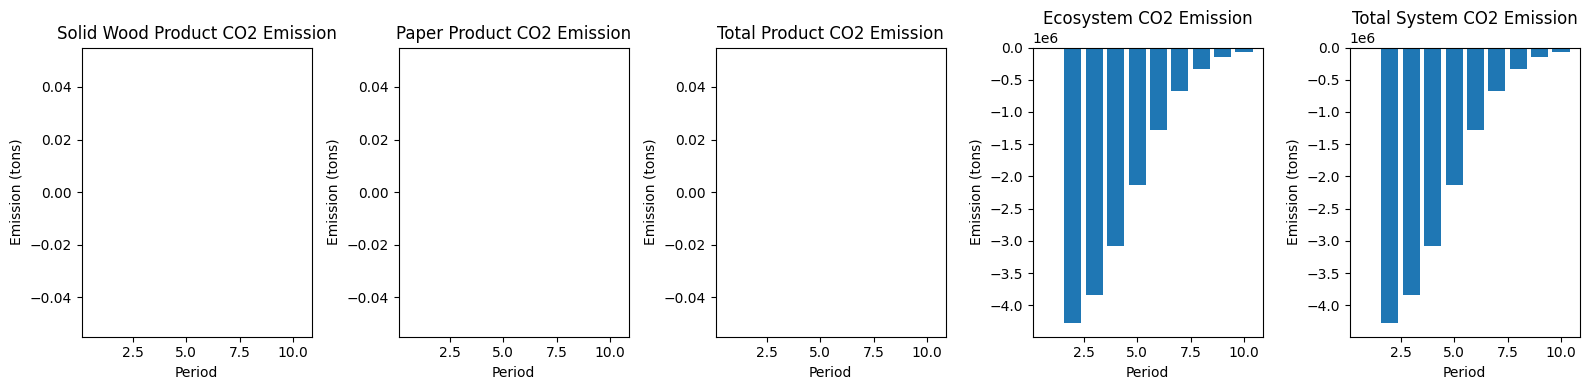

In [30]:
track_system_emission(fm)

In [31]:
print('It took', round((time.time() - Start) / 60, 1), "minutes to run this script.")

It took 4.9 minutes to run this script.
